In [ ]:
from google.colab import files
uploaded = files.upload()

Saving chronic_kidney_disease_full.csv to chronic_kidney_disease_full (1).csv
Saving Risk Factor Prediction of Chronic Kidney Disease.csv to Risk Factor Prediction of Chronic Kidney Disease (1).csv


## NephroAI - Data Integration
Turning the two CKD datasets (UCI + Enam Medical College) into ONE unified table.
The two files describe the same kind of patient info in totally different formats
(raw numbers vs. pre-made ranges, yes/no vs 1/0, different column names) - every


In [ ]:
import pandas as pd
import numpy as np

### Step 1: Load the UCI dataset the "safe" way
The raw file has a sneaky problem - one row has an extra stray value in it,
which pushes every column after that point one slot to the right. Reading it
normally would either error out or silently misalign that row's data. So we
read it carefully with an extra placeholder column to catch that overflow.

In [ ]:
uci_columns = ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
               'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc',
               'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']

uci_raw = pd.read_csv(
    'chronic_kidney_disease_full.csv',
    header=None,
    skiprows=1,                       # skip the original header line, we're naming columns ourselves
    names=uci_columns + ['extra'],    # the extra slot catches the overflow from that broken row
    engine='python',
    on_bad_lines='warn'
)

# That one broken row can't be trusted - its values are scrambled, not just
# missing. Rather than guess where each value should go, we just drop it.
uci_raw = uci_raw.drop(index=369).drop(columns=['extra']).reset_index(drop=True)

### Step 2: Clean up the messy text in the UCI file
Real clinical data exports are never as clean as they look. Some cells have
hidden tabs/spaces, and missing values are written as "?" instead of a real
blank - so pandas won't recognise them as missing unless we tell it to.

In [ ]:
text_columns = uci_raw.select_dtypes(include='object').columns
for col in text_columns:
    uci_raw[col] = uci_raw[col].astype(str).str.strip()

uci_raw = uci_raw.replace('?', np.nan)     # now "missing" actually means missing
uci_raw['class'] = uci_raw['class'].str.strip()

# A handful of columns should be real numbers, not text - convert them,
# anything that fails to convert becomes NaN instead of crashing.
numeric_columns = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
for col in numeric_columns:
    uci_raw[col] = pd.to_numeric(uci_raw[col], errors='coerce')

uci_clean = uci_raw.copy()

### Step 3: Load the Enam Medical College dataset
This file has two junk rows right after the header (a "data type" row and a
mostly-blank row) before real patient data starts - skip those two specifically.

In [ ]:
enam_raw = pd.read_csv(
    'Risk Factor Prediction of Chronic Kidney Disease.csv',
    skiprows=[1, 2]
)

### Step 4: Figure out exactly how Enam built its number ranges
Every numeric column in Enam isn't a real number - it's already chopped into
ranges like "112 - 154". To make UCI match, we reverse-engineer the exact rule
(starting point, ending point, step size) so UCI's real numbers can be sorted
into the exact same buckets, instead of inventing our own arbitrary ranges.

In [ ]:
def find_bin_rule(series):
    """Work out the starting edge, ending edge, and step size Enam used
    for a column, just by looking at the range-labels it left behind."""
    labels = series.astype(str).unique()
    lower_edges = []
    for label in labels:
        label = label.strip()
        if label.startswith('<'):
            continue                                   # open lower end, skip it
        elif label.startswith('≥'):
            lower_edges.append(float(label.replace('≥', '').strip()))
        elif '-' in label:
            lower_edges.append(float(label.split('-')[0].strip()))

    lower_edges = sorted(set(lower_edges))
    gaps = [round(b - a, 6) for a, b in zip(lower_edges[:-1], lower_edges[1:])]
    step = min(gaps) if gaps else None
    return min(lower_edges), max(lower_edges), step

numeric_cols_to_align = ['bgr', 'bu', 'sod', 'sc', 'pot', 'hemo', 'pcv', 'rbcc', 'wbcc']

bin_rules = {}
for col in numeric_cols_to_align:
    bin_rules[col] = find_bin_rule(enam_raw[col])
# Confirmed by hand: every one of these turned out to be clean, evenly-spaced
# ranges - good news, means we can rebuild them exactly.

### Step 5: Apply Enam's exact ranges to UCI's real numbers
Formatting matters here - Enam writes whole numbers without a decimal point
("112 - 154"). If our code wrote "112.0 - 154.0" instead, a computer would
treat those as two different categories even though they mean the same thing.

In [ ]:
def format_number(x):
    x = round(x, 4)
    return str(int(x)) if x == int(x) else str(x)

def sort_into_enam_ranges(values, lo, hi, step):
    """Sort a column of real numbers into the same range-buckets Enam used,
    with open ends so nothing ever falls outside."""
    edges = list(np.arange(lo, hi + step / 2, step))
    edges = [-np.inf] + edges + [np.inf]

    labels = []
    for i in range(len(edges) - 1):
        if edges[i] == -np.inf:
            labels.append(f"< {format_number(lo)}")
        elif edges[i + 1] == np.inf:
            labels.append(f"≥ {format_number(hi)}")
        else:
            labels.append(f"{format_number(edges[i])} - {format_number(edges[i+1])}")

    return pd.cut(values, bins=edges, labels=labels, right=False)

uci_binned = uci_clean.copy()
for col, (lo, hi, step) in bin_rules.items():
    uci_binned[col] = sort_into_enam_ranges(uci_clean[col], lo, hi, step).astype(str)
    uci_binned.loc[uci_clean[col].isna(), col] = np.nan   # keep real missing values as missing

### Step 6: Age gets the same treatment (its own range pattern)

In [ ]:
age_edges = [-np.inf, 12, 20, 27, 35, 43, 51, 59, 66, 74, np.inf]
age_labels = ['< 12', '12 - 20', '20 - 27', '27 - 35', '35 - 43',
              '43 - 51', '51 - 59', '59 - 66', '66 - 74', '≥ 74']
uci_binned['age'] = pd.cut(uci_clean['age'], bins=age_edges, labels=age_labels, right=False).astype(str)
uci_binned.loc[uci_clean['age'].isna(), 'age'] = np.nan

### Step 7: Specific gravity - a direct lookup, not a range calculation
It only ever takes 5 fixed values in UCI, and Enam has one matching range
for each - so no math needed, just a straightforward one-to-one map.

In [ ]:
sg_lookup = {
    1.005: '< 1.007',
    1.010: '1.009 - 1.011',
    1.015: '1.015 - 1.017',
    1.020: '1.019 - 1.021',
    1.025: '≥ 1.023'
}
uci_binned['sg'] = uci_clean['sg'].map(sg_lookup)

### Step 8: Albumin and sugar - already 0-5 scores, not raw numbers
Enam grouped these into "0", "1", "2", "3", "4 or more" buckets, so we just
slot UCI's existing 0-5 scores into the same groups.

In [ ]:
def group_albumin_sugar_score(value):
    if pd.isna(value):
        return np.nan
    value = int(value)
    if value <= 0:
        return '< 0'
    elif value == 1:
        return '1 - 1'
    elif value == 2:
        return '2 - 2'
    elif value == 3:
        return '3 - 3'
    else:
        return '≥ 4'

uci_binned['al'] = uci_clean['al'].apply(group_albumin_sugar_score)
uci_binned['su'] = uci_clean['su'].apply(group_albumin_sugar_score)
# Side note: Enam's OWN "su" ranges turned out to be a bit inconsistent/overlapping
# to begin with (not our doing) - flagged as a known limitation, not silently fixed.

### Step 9: Match up the yes/no columns to Enam's 1/0 style
UCI writes these as words, Enam writes them as 1/0. We checked the direction
by comparing each column against the CKD label - 1 always means "the risky/
abnormal thing is present", consistently, across every one of these columns.

In [ ]:
yes_no_lookup = {
    'rbc':   {'normal': 0, 'abnormal': 1},
    'pc':    {'normal': 0, 'abnormal': 1},
    'pcc':   {'notpresent': 0, 'present': 1},
    'ba':    {'notpresent': 0, 'present': 1},
    'htn':   {'no': 0, 'yes': 1},
    'dm':    {'no': 0, 'yes': 1},
    'cad':   {'no': 0, 'yes': 1},
    'appet': {'good': 0, 'poor': 1},
    'pe':    {'no': 0, 'yes': 1},
    'ane':   {'no': 0, 'yes': 1},
}
for col, lookup in yes_no_lookup.items():
    uci_binned[col] = uci_clean[col].map(lookup)

### Step 10: Blood pressure - UCI gives one number, Enam gives two columns
Enam splits BP into "is it high at all" (yes/no) and "how high" (a 3-level
severity score). UCI only has the raw number, so we rebuild both columns
using standard high-blood-pressure cutoffs - the one place we're applying
outside medical knowledge rather than reverse-engineering it from the data.

In [ ]:
def bp_is_high(value):
    if pd.isna(value):
        return np.nan
    return 0 if value < 90 else 1

def bp_severity_level(value):
    if pd.isna(value):
        return np.nan
    if value < 90:
        return 0
    elif value < 100:
        return 1
    else:
        return 2

uci_binned['bp (Diastolic)'] = uci_clean['bp'].apply(bp_is_high)
uci_binned['bp limit'] = uci_clean['bp'].apply(bp_severity_level)
uci_binned = uci_binned.drop(columns=['bp'])   # replaced by the two columns above

### Step 11: Line up both tables and stack them into one
We only keep columns that genuinely exist in both datasets. Leaving out
"affected" (a copy of "class" - would let the model cheat) and "stage"/"grf"
(only in Enam, can't be worked out for UCI without patient sex, which
neither file has).

In [ ]:
shared_columns = ['bp (Diastolic)', 'bp limit', 'sg', 'al', 'class', 'rbc', 'su',
                  'pc', 'pcc', 'ba', 'bgr', 'bu', 'sod', 'sc', 'pot', 'hemo',
                  'pcv', 'rbcc', 'wbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'age']

uci_final = uci_binned[shared_columns].copy()
uci_final['source'] = 'UCI'          # track where each row came from, useful later

enam_final = enam_raw[shared_columns].copy()
enam_final['source'] = 'Enam'

combined = pd.concat([uci_final, enam_final], ignore_index=True)

### Step 12: Double-check our own work before trusting this dataset
Making sure the categories we built for UCI actually match Enam's real
categories - if they don't, the whole point of this exercise falls apart silently.

In [ ]:
print("Checking that our rebuilt ranges actually match Enam's real ranges...")
for col in numeric_cols_to_align + ['age', 'sg', 'al', 'su']:
    uci_categories = set(uci_final[col].dropna().unique())
    enam_categories = set(enam_final[col].dropna().unique())
    extra_categories = uci_categories - enam_categories
    if extra_categories:
        print(f"  Note - '{col}': UCI produced some ranges Enam's smaller "
              f"sample never happened to show -> {extra_categories}")

print()
print("Final combined dataset shape:", combined.shape)
print("Patients from each source:", combined['source'].value_counts().to_dict())
print("CKD vs non-CKD balance:")
print(combined['class'].value_counts())

# Save the final result so we don't have to redo any of this next time.
combined.to_csv('ckd_combined_unified.csv', index=False)
print("\nSaved as ckd_combined_unified.csv")

Checking that our rebuilt ranges actually match Enam's real ranges...
  Note - 'bu': UCI produced some ranges Enam's smaller sample never happened to show -> {'314.8 - 352.9', '276.7 - 314.8'}
  Note - 'sc': UCI produced some ranges Enam's smaller sample never happened to show -> {'22.55 - 25.7'}
  Note - 'su': UCI produced some ranges Enam's smaller sample never happened to show -> {'3 - 3', '1 - 1'}

Final combined dataset shape: (599, 27)
Patients from each source: {'UCI': 399, 'Enam': 200}
CKD vs non-CKD balance:
class
ckd       378
notckd    221
Name: count, dtype: int64

Saved as ckd_combined_unified.csv


### Step 13: Train/test split + missing value imputation
Splitting first, then filling in missing values using ONLY what the training
data can teach us - this avoids letting test-set information leak into training.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import pandas as pd

df = pd.read_csv("ckd_combined_unified.csv")

### Separate features from the target, and drop 'source'
'source' just tells us which hospital/dataset a patient came from - it's
not something a doctor could measure on a real patient, so it shouldn't
be something the model learns to rely on. Keeping it around risks the
model quietly learning "which dataset" instead of "does this patient have CKD".

In [ ]:
X = df.drop(columns=['class', 'source'])
y = df['class']

### Split FIRST, before touching any missing values
Doing this before imputation matters - if we filled in missing values using
the whole dataset, information from the test set would quietly leak into
training, and our accuracy later would look better than it really should.
stratify=y keeps the ckd/non-ckd ratio the same in both sets, important
since our classes aren't perfectly balanced (63% / 37%).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (479, 25)  Test size: (120, 25)


### Fill missing values using only what the training data can teach us
Our columns are categorical now (bins and 0/1 flags, not raw numbers), so
"most frequent value" is the right fill strategy here - averaging category
labels wouldn't make sense the way it would for plain numeric columns.

In [ ]:
imputer = SimpleImputer(strategy='most_frequent')
imputer.fit(X_train)                     # the imputer only ever looks at training rows

SimpleImputer(strategy='most_frequent')

### Apply that same learned rule to both sets
fit_transform on train, but just transform (no fit) on test - this one
step is the whole trick that keeps the test set "unseen" and honest.

In [ ]:
X_train = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns,  index=X_test.index)

print("Missing values left in training set:", X_train.isnull().sum().sum())
print("Missing values left in test set:", X_test.isnull().sum().sum())

Missing values left in training set: 0
Missing values left in test set: 0


.......

### Step 14: Encoding - turning category labels into real numbers
The binary columns got turned into text ("0"/"1") by the imputer step, and
the range-bin columns are still plain strings like "112 - 154" - neither is
something a model can actually train on yet.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

# columns that are already just 0/1 flags, just need converting back to real numbers
binary_cols = ['bp (Diastolic)', 'rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

for col in binary_cols:
    X_train[col] = X_train[col].astype(int)
    X_test[col]  = X_test[col].astype(int)

# 'bp limit' is already a 0/1/2 severity score, same deal
X_train['bp limit'] = X_train['bp limit'].astype(int)
X_test['bp limit']  = X_test['bp limit'].astype(int)

### Ordinal columns - order matters, so we build the category order ourselves
rather than letting the encoder guess it from whatever it happens to see first.

In [ ]:
ordinal_cols = ['sg', 'al', 'su', 'bgr', 'bu', 'sod', 'sc', 'pot', 'hemo', 'pcv', 'rbcc', 'wbcc', 'age']

def bin_sort_key(label):
    """Turns a range-label like '3.65 - 6.8' into a number we can sort by,
    so '< 3.65' always comes first and '≥ 28.85' always comes last."""
    label = label.strip()
    if label.startswith('<'):
        return -np.inf
    elif label.startswith('≥'):
        return float(label.replace('≥', '').strip())
    else:
        return float(label.split('-')[0].strip())

# work out every category that appears in EITHER train or test, so nothing
# gets left out and causes a crash later on a rare bin we haven't seen yet
category_orders = []
for col in ordinal_cols:
    all_labels = set(X_train[col].unique()) | set(X_test[col].unique())
    sorted_labels = sorted(all_labels, key=bin_sort_key)
    category_orders.append(sorted_labels)

encoder = OrdinalEncoder(categories=category_orders, handle_unknown='use_encoded_value', unknown_value=-1)
encoder.fit(X_train[ordinal_cols])   # still only "fitting" the mechanics on train, categories are pre-defined

X_train[ordinal_cols] = encoder.transform(X_train[ordinal_cols])
X_test[ordinal_cols]  = encoder.transform(X_test[ordinal_cols])

### Encode the target label too - "ckd"/"notckd" text needs to become 0/1

In [ ]:
y_train = y_train.map({'notckd': 0, 'ckd': 1})
y_test  = y_test.map({'notckd': 0, 'ckd': 1})

### Sanity check - everything should be numeric now, nothing left as text

In [ ]:
print(X_train.dtypes.value_counts())
print()
print("Any missing values snuck back in? ->", X_train.isnull().sum().sum(), X_test.isnull().sum().sum())
print(X_train.head())

float64    13
int64      12
Name: count, dtype: int64

Any missing values snuck back in? -> 0 0
     bp (Diastolic)  bp limit   sg   al  rbc   su  pc  pcc  ba  bgr  ...  pcv  \
590               0         0  3.0  0.0    0  0.0   0    0   0  0.0  ...  6.0   
175               0         0  3.0  0.0    0  0.0   0    0   0  4.0  ...  6.0   
66                0         0  3.0  2.0    1  0.0   0    0   0  1.0  ...  6.0   
419               1         1  3.0  0.0    0  0.0   0    0   0  0.0  ...  9.0   
519               0         0  1.0  0.0    0  0.0   0    0   0  4.0  ...  6.0   

     rbcc  wbcc  htn  dm  cad  appet  pe  ane  age  
590   6.0   2.0    0   0    0      0   0    0  9.0  
175   2.0   0.0    1   0    0      0   0    0  7.0  
66    4.0   2.0    1   1    0      0   1    0  8.0  
419   4.0   3.0    0   0    0      0   0    0  3.0  
519   2.0   0.0    1   0    0      0   0    0  7.0  

[5 rows x 25 columns]


### Step 15: Scale features, then train a Logistic Regression baseline
Scaling matters here because Logistic Regression is sensitive to a feature's
raw numeric range - a column that goes 0-9 shouldn't dominate a 0/1 column
just because its numbers happen to be bigger.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)                 # again, only ever learning from training data

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### Train the baseline model

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Evaluate it - and NOT just with accuracy
Accuracy alone can be misleading on imbalanced data (remember paper 7 from
your literature review - 97.5% accuracy but missed real CKD cases). Recall
on the CKD-positive class specifically matters most in a medical context,
since missing a sick patient is worse than a false alarm.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = log_reg.predict(X_test_scaled)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print()
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=['notckd','ckd']))

Accuracy:  0.975
Precision: 0.9866666666666667
Recall:    0.9736842105263158
F1 score:  0.9801324503311258

Confusion matrix:
[[43  1]
 [ 2 74]]

              precision    recall  f1-score   support

      notckd       0.96      0.98      0.97        44
         ckd       0.99      0.97      0.98        76

    accuracy                           0.97       120
   macro avg       0.97      0.98      0.97       120
weighted avg       0.98      0.97      0.98       120



### Step 16: Cross-validation - checking this result isn't just a lucky split
One 80/20 split on 599 patients means the test set is only 120 people - small
enough that a single unlucky/lucky split could swing accuracy by a few points.
Cross-validation re-splits the data several times and averages the results,
giving a far more trustworthy number to actually report.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# we scale + impute inside this properly by wrapping steps in a pipeline,
# so each fold learns its own imputation/scaling rules from only its own
# training portion - same leakage-avoidance principle as before, just
# repeated automatically across every fold instead of doing it by hand once
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# note: we run this on X (before our earlier manual split/encode), so the
# ordinal encoding still needs to happen first - for now this reuses the
# already-encoded X_train + X_test stacked back together, just for the CV check
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

scores = cross_val_score(pipeline, X_full, y_full, cv=cv, scoring='recall')

print("Recall across 5 folds:", scores)
print("Average recall:", scores.mean().round(4), " (+/-", scores.std().round(4), ")")

Recall across 5 folds: [1.         0.98684211 0.98684211 0.98684211 0.94666667]
Average recall: 0.9814  (+/- 0.0181 )


### Step 17: Random Forest + XGBoost - building the comparison table
Reusing the exact same pipeline structure as the Logistic Regression baseline,
so the comparison is fair - same folds, same preprocessing, only the model changes.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# note: tree-based models don't actually need the StandardScaler step (they
# split on thresholds, not distances) - but leaving it in doesn't hurt them
# either, and keeping the pipeline identical across models makes the
# comparison cleaner and easier to defend than changing steps per-model.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

scoring = ['accuracy', 'precision', 'recall', 'f1']
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('scale', StandardScaler()),
        ('model', model)
    ])
    scores = cross_validate(pipeline, X_full, y_full, cv=cv, scoring=scoring)
    results.append({
        'Model': name,
        'Accuracy':  scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall':    scores['test_recall'].mean(),
        'F1':        scores['test_f1'].mean(),
    })


### The comparison table

In [ ]:
comparison_df = pd.DataFrame(results).round(4)
print(comparison_df.to_string(index=False))

              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.9833     0.9922  0.9814 0.9866
      Random Forest    0.9849     0.9921  0.9840 0.9879
            XGBoost    0.9783     0.9819  0.9841 0.9828


### Step 18: Train the final Random Forest, then explain it with SHAP
We're skipping the scaling step here on purpose - trees don't need it, and
keeping features in their original, human-readable form (not standardized
numbers) makes the SHAP plots actually meaningful to look at.

In [ ]:
# !pip install shap    # uncomment/run this once if shap isn't already installed
import shap
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(n_estimators=200, random_state=42)
final_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

### Global explanation - which features matter most, overall

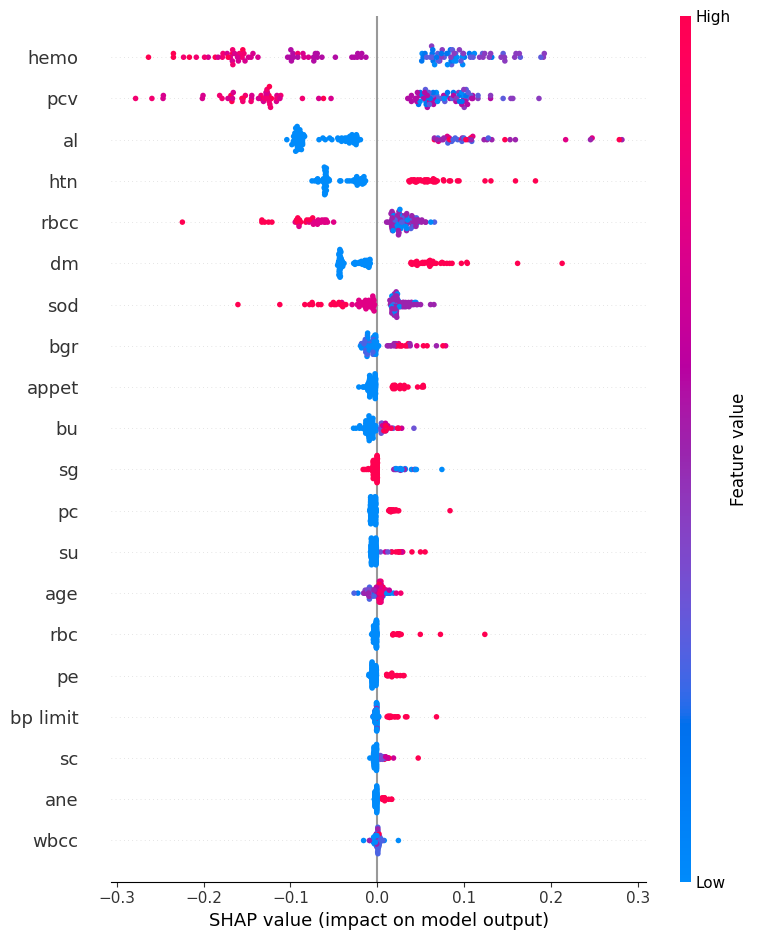

In [ ]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# for a binary classifier, shap_values is a list [class_0_values, class_1_values] -
# we care about class 1 (ckd), since that's the "positive" case we're explaining
shap.summary_plot(shap_values[:,:,1], X_test, feature_names=X_test.columns)

### Local explanation - why ONE specific patient was flagged
Picking test patient at row 0 as an example - swap the index to look at any other patient.

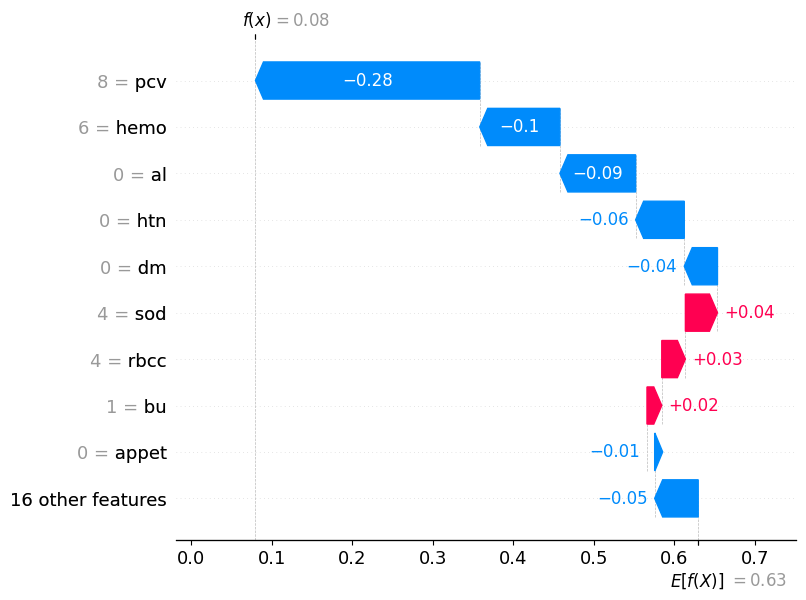

In [ ]:
patient_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[patient_index,:,1],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[patient_index],
        feature_names=X_test.columns.tolist()
    )
)

### Step 19: Save the trained model + preprocessing steps for later use
The model alone isn't enough - it only understands encoded numbers, not raw
patient inputs. We need the imputer and encoder saved too, so a new patient's
raw form values can be turned into that same encoded shape before prediction.

In [ ]:
import joblib

joblib.dump(final_model, 'ckd_random_forest_model.pkl')
joblib.dump(imputer, 'ckd_imputer.pkl')
joblib.dump(encoder, 'ckd_ordinal_encoder.pkl')

# also save the exact column order/lists - the app will need to know which
# columns are binary vs ordinal, and in what order, to rebuild a matching row
joblib.dump({
    'binary_cols': binary_cols,
    'ordinal_cols': ordinal_cols,
    'feature_order': list(X_train.columns)
}, 'ckd_feature_metadata.pkl')

print("Saved: model, imputer, encoder, and feature metadata")

Saved: model, imputer, encoder, and feature metadata


In [ ]:
from google.colab import files

for fname in ['ckd_random_forest_model.pkl', 'ckd_imputer.pkl',
              'ckd_ordinal_encoder.pkl', 'ckd_feature_metadata.pkl']:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>